In [ ]:
# 本实验要训练模型根据讲课所用幻灯片数量推算本节课的时长
import numpy as np
import matplotlib.pyplot as plt
# 2021年部分课程的页数与时长数据
page_2021 = np.array([61, 29, 16, 21, 19, 9, 35, 43, 14, 60, 95, 67, 38, 39, 42, 16, 64, 34, 37, 57])
duration_2021 = np.array([109, 51, 34, 31, 38, 19, 56, 74, 31, 93, 160, 99, 49, 76, 72, 35, 165, 68, 86, 78])

# 2024年部分课程的页数与时长数据
page_2024 = np.array([27, 22, 27, 50, 49, 16, 24, 37, 33, 27, 36, 27, 36, 30, 16, 41, 62, 34])
word_2024 = np.array([2236, 1457, 1309, 3404, 2513, 764, 1448, 2327, 2006, 1224, 1121, 1042, 1040, 1029, 1048, 1946, 2631, 1846])
duration_2024 = np.array([35, 30, 26, 35, 47, 25, 35, 38, 37, 25, 38, 45, 46, 32, 15, 45, 87, 38])

# 2025年部分课程的页数，总字数，时长数据
page_2025 = np.array([27, 35, 77, 69, 97])
word_2025 = np.array([2616, 2042, 2665, 2317, 3923])
duration_2025 = np.array([31, 48, 95, 82, 120])
# 训练数据
x1_train = page_2021  # 函数输入
y_train = duration_2021  # 正确答案

# 验证数据
x1_val = page_2025
y_val = duration_2025


def mse(pred, truth):
    return np.mean((pred - truth) ** 2)


# 我们先假设是线性关系：
# y=w*x+b,y:课程时长，x:幻灯片页数，w,b:待确认参数
def linear(x1, w1, b1):
    return w1 * x1 + b1


In [ ]:
w1_range=np.linspace(0,3,100)
b_range=np.linspace(0,20,300)
losses=np.zeros((len(b_range),len(w1_range)))
for i,b in enumerate(b_range):
    for j,w in enumerate(w1_range):
        pred=linear(x1_train,w,b)
        losses[i,j]=mse(pred,y_train)



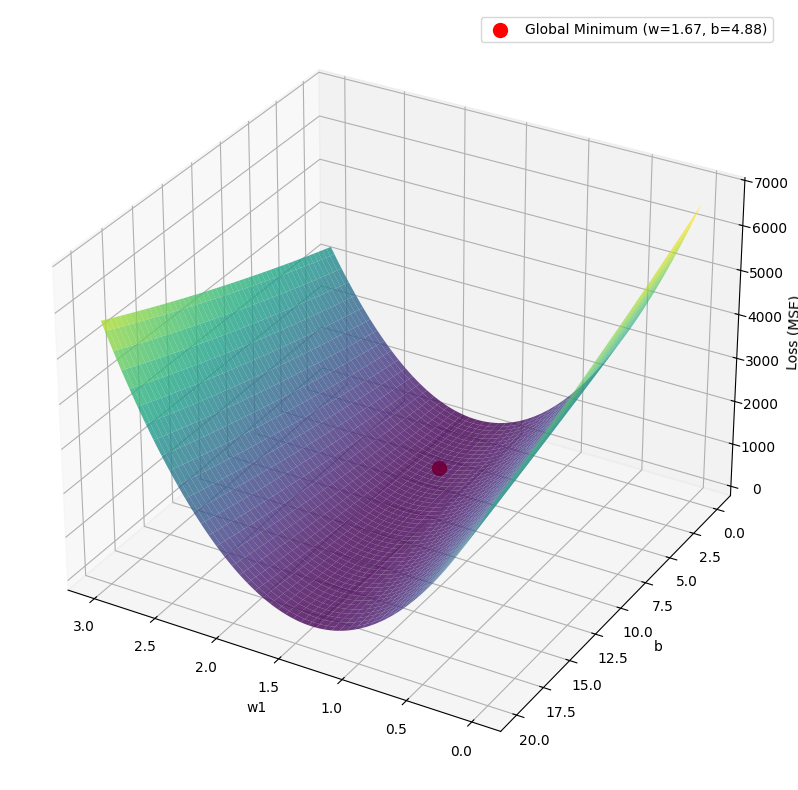

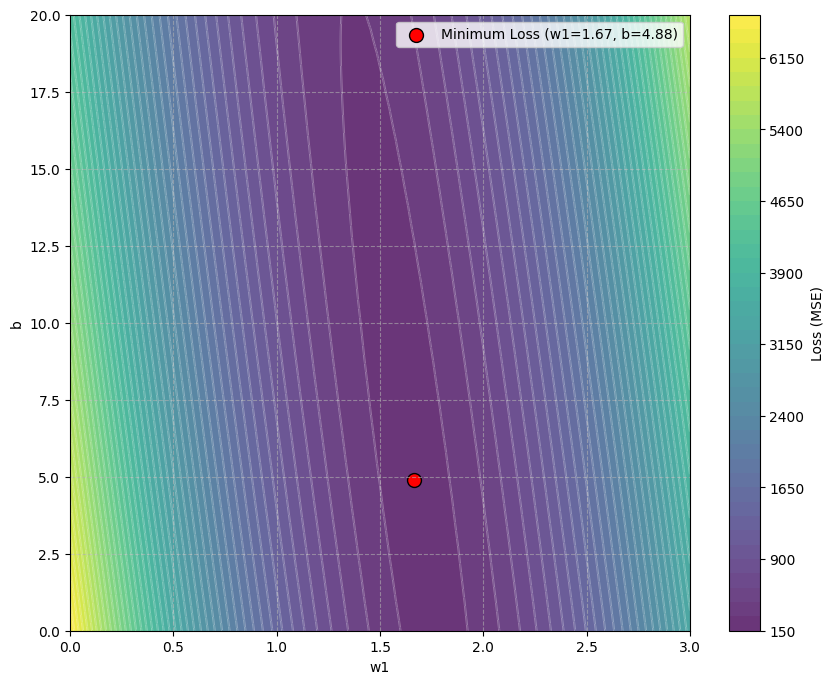

透過暴力法找到的最佳參數: w ≈ 1.67, b ≈ 4.88, 對應的最小 Loss ≈ 240.36


In [ ]:
# --- 繪製 Loss Surface ---

# 1. 3D 曲面圖
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(projection='3d')
W, B = np.meshgrid(w1_range, b_range)
ax.plot_surface(W, B, losses, cmap='viridis', alpha=0.8)
ax.set_xlabel('w1')
ax.set_ylabel('b')
ax.set_zlabel('Loss (MSE)')
ax.view_init(elev=30, azim=120)

# 標示出最低點
min_loss_idx = np.unravel_index(np.argmin(losses), losses.shape) #找出 losses 陣列中「最小值的位置」
min_w = W[min_loss_idx]
min_b = B[min_loss_idx]
min_loss = losses[min_loss_idx]
ax.scatter(min_w, min_b, min_loss, color='red', s=100, label=f'Global Minimum (w={min_w:.2f}, b={min_b:.2f})')
ax.legend()

plt.show()


# 2. D 等高線圖 (Contour Plot)
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=50, cmap='viridis', alpha=0.8)
plt.contour(W, B, losses, levels=50, colors='white', alpha=0.3)
plt.colorbar(contour, label='Loss (MSE)')
plt.xlabel('w1')
plt.ylabel('b')

# 標示出最低點
plt.scatter(min_w, min_b, color='red', s=100, edgecolor='black', label=f'Minimum Loss (w1={min_w:.2f}, b={min_b:.2f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"透過暴力法找到的最佳參數: w ≈ {min_w:.2f}, b ≈ {min_b:.2f}, 對應的最小 Loss ≈ {min_loss:.2f}")

In [ ]:
w1=1
b=15
w1_history=[]
b_history=[]
loss_history=[]
w1_history.append(w1)
b_history.append(b)
cur_loss=mse(linear(x1_train,w1,b),y_train)
loss_history.append(cur_loss)
lr=0.0001
epochs=10000
N=len(x1_train)
for epoch in range(epochs):
    pred=linear(x1_train,w1,b)
    gradw=(2/N)*np.sum((pred-y_train)*x1_train)
    gradb=(2/N)*np.sum(pred-y_train)
    w1=w1-lr*gradw
    b=b-lr*gradb
    w1_history.append(w1)
    b_history.append(b)
    loss=mse(linear(x1_train,w1,b),y_train)
    loss_history.append(loss)
    


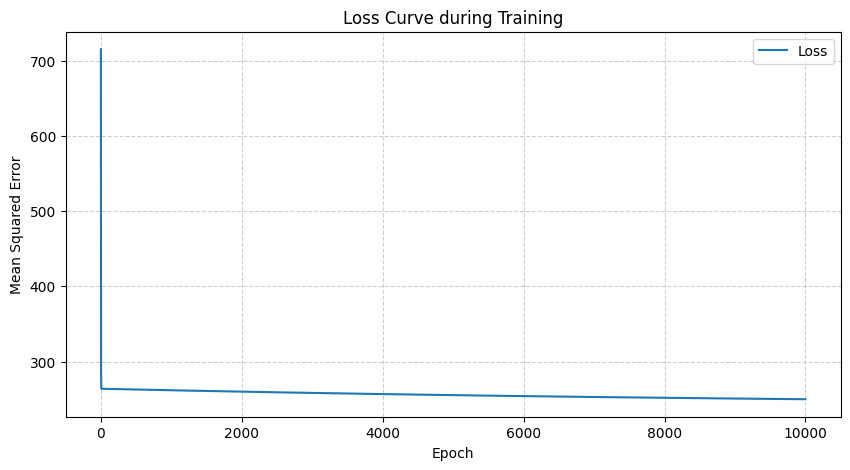

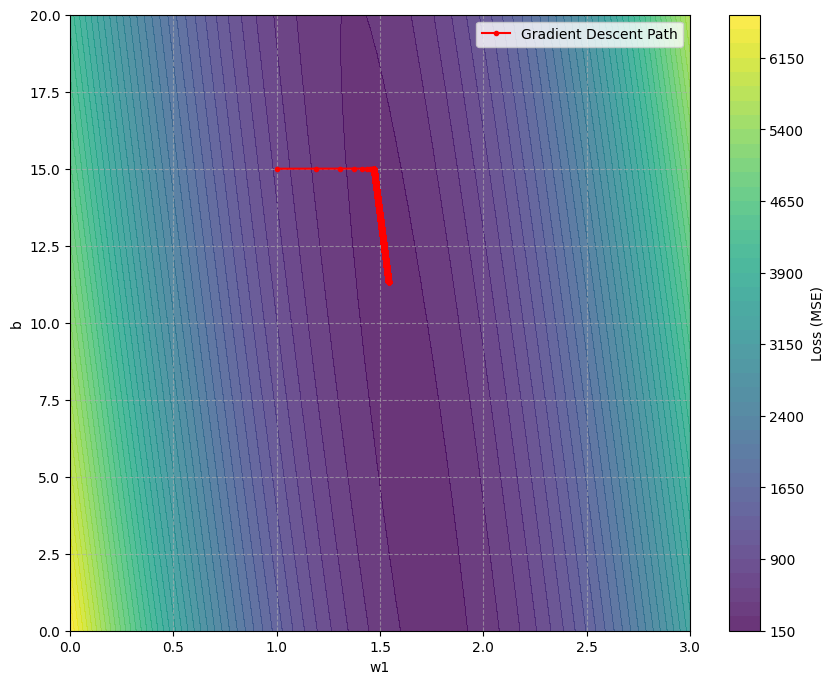

In [ ]:
# --- 視覺化訓練過程 ---

# 1. 畫出 Loss 下降的曲線
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.title('Loss Curve during Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 2. 在 Loss Surface 上畫出梯度下降的路徑
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss (MSE)')
plt.plot(w1_history, b_history, 'r-o', markersize=3, label='Gradient Descent Path' ) #
#plt.title('Gradient Descent Path on Error Surface')
plt.xlabel('w1')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Limit the plot range to match the contour plot
plt.xlim(w1_range.min(), w1_range.max())
plt.ylim(b_range.min(), b_range.max())

plt.show()

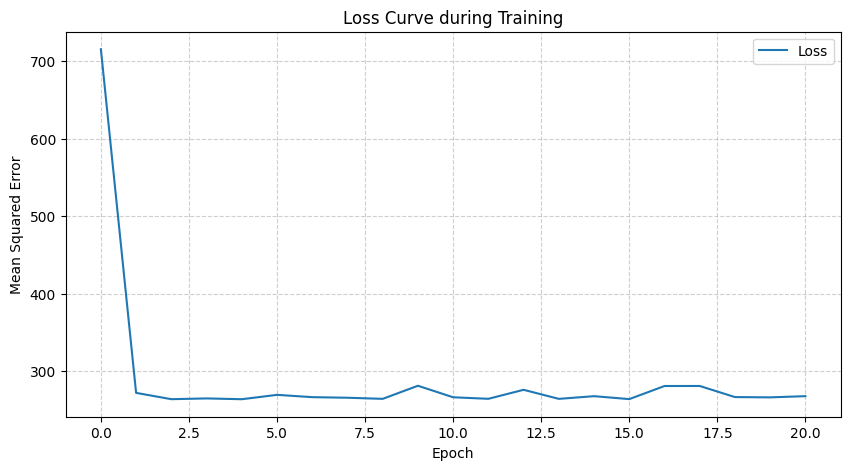

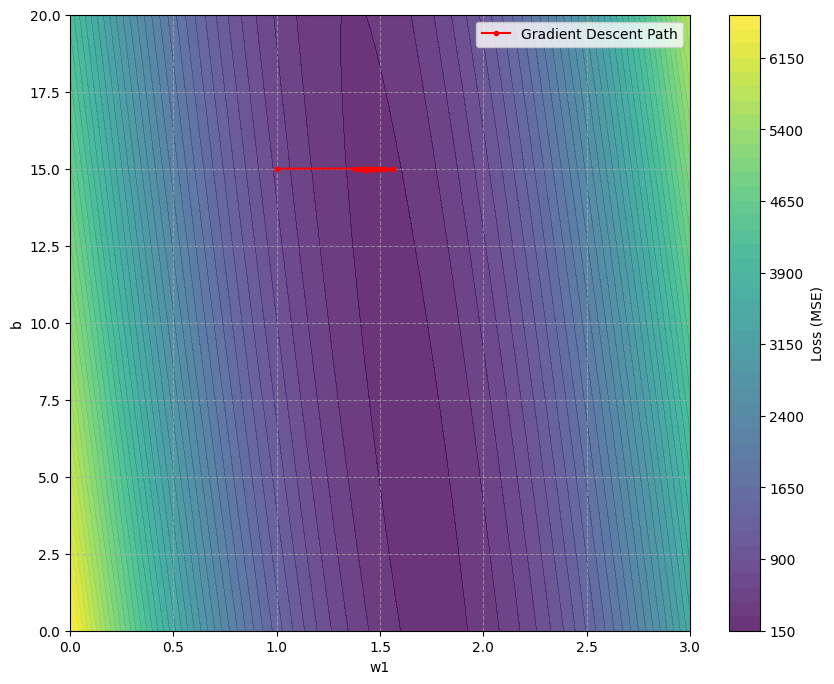

In [ ]:
w1_mini=1
b_mini=15
w1_history_mini=[w1_mini]
b_history_mini=[b_mini]
cur_loss=mse(linear(x1_train,w1_mini,b_mini),y_train)
loss_history_mini=[cur_loss]
epochs=20
lr_mini=0.0001
batch_size=5
batch_cnt=int(np.ceil(len(x1_train)/batch_size))
for _ in range(epochs):
    shuffle_indices=np.random.permutation(len(x1_train))
    x1_shuffled=x1_train[shuffle_indices]
    y_shuffled=y_train[shuffle_indices]
    for i in range(batch_cnt):
        st=i*batch_size
        en=(i+1)*batch_size
        x1_batch=x1_shuffled[st:en]
        y_batch=y_shuffled[st:en]
        pred_batch=linear(x1_batch,w1_mini,b_mini)
        N_batch=len(x1_batch)
        gradw=(2/N_batch)*np.sum((pred_batch-y_batch)*x1_batch)
        gradb=(2/N_batch)*np.sum(pred_batch-y_batch)
        w1_mini=w1_mini-lr_mini*gradw
        b_mini=b_mini-lr_mini*gradb
    w1_history_mini.append(w1_mini)
    b_history_mini.append(b_mini)
    cur_loss=mse(linear(x1_train,w1_mini,b_mini),y_train)
    loss_history_mini.append(cur_loss)
# 畫出 Loss 下降的曲線
plt.figure(figsize=(10, 5))
plt.plot(loss_history_mini, label='Loss')
plt.title('Loss Curve during Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 在 Loss Surface 上畫出梯度下降的路徑
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss (MSE)')
plt.plot(w1_history_mini, b_history_mini, 'r-o', markersize=3, label='Gradient Descent Path' )
#plt.title('Gradient Descent Path on Error Surface')
plt.xlabel('w1')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Limit the plot range to match the contour plot
plt.xlim(w1_range.min(), w1_range.max())
plt.ylim(b_range.min(), b_range.max())

plt.show()

In [ ]:
loss1=mse(linear(x1_val,w1,b),y_val)
print(f"w={w1:.2f},b={b:.2f},loss={loss1:.2f}")
loss2=mse(linear(x1_val,w1_mini,b_mini),y_val)
print(f"w={w1_mini:.2f},b={b_mini:.2f},loss={loss2:.2f}")


w=1.54,b=11.31,loss=989.21
w=1.43,b=14.97,loss=752.52


In [ ]:
#换一组数据重新训练
x1_train=page_2024
y_train=duration_2024

In [ ]:
w1_range=np.linspace(0,3,100)
b_range=np.linspace(0,20,300)
losses=np.zeros((len(b_range),len(w1_range)))
for i,b in enumerate(b_range):
    for j,w in enumerate(w1_range):
        pred=linear(x1_train,w,b)
        losses[i,j]=mse(pred,y_train)



In [ ]:
w1=1
b=15
w1_history=[]
b_history=[]
loss_history=[]
w1_history.append(w1)
b_history.append(b)
cur_loss=mse(linear(x1_train,w1,b),y_train)
loss_history.append(cur_loss)
lr=0.0001
epochs=10000
N=len(x1_train)
for epoch in range(epochs):
    pred=linear(x1_train,w1,b)
    gradw=(2/N)*np.sum((pred-y_train)*x1_train)
    gradb=(2/N)*np.sum(pred-y_train)
    w1=w1-lr*gradw
    b=b-lr*gradb
    w1_history.append(w1)
    b_history.append(b)
    loss=mse(linear(x1_train,w1,b),y_train)
    loss_history.append(loss)
    


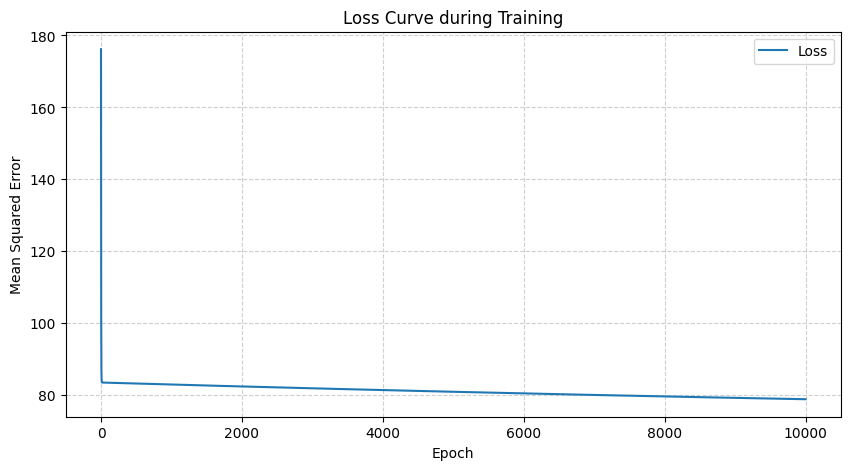

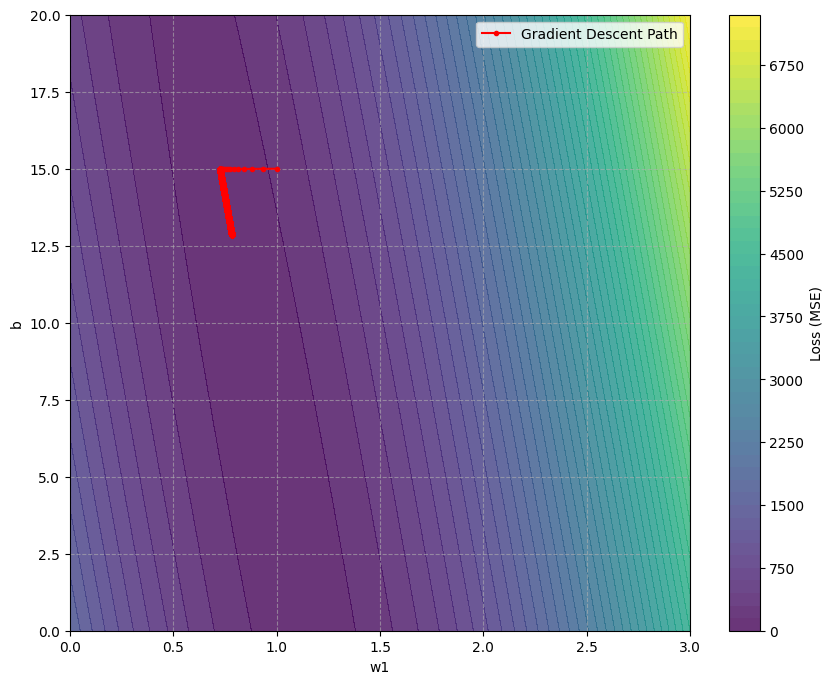

In [ ]:
# --- 視覺化訓練過程 ---

# 1. 畫出 Loss 下降的曲線
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.title('Loss Curve during Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 2. 在 Loss Surface 上畫出梯度下降的路徑
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss (MSE)')
plt.plot(w1_history, b_history, 'r-o', markersize=3, label='Gradient Descent Path' ) #
#plt.title('Gradient Descent Path on Error Surface')
plt.xlabel('w1')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Limit the plot range to match the contour plot
plt.xlim(w1_range.min(), w1_range.max())
plt.ylim(b_range.min(), b_range.max())

plt.show()

In [ ]:
loss1=mse(linear(x1_val,w1,b),y_val)
print(f"w={w1:.2f},b={b:.2f},loss={loss1:.2f}")



w=0.78,b=12.84,loss=349.83


In [ ]:
#换一个模型
def linear2(x1,x2,w1,w2,b):
    return w1*x1+w2*x2+b
x2_train=word_2024
x2_val=word_2025

In [ ]:
w1=1
w2=1
b=15
epochs=10000
lr=0.0000001
pred=linear2(x1_train,x2_train,w1,w2,b)
cur_loss=mse(pred,y_train)
for _ in range(epochs):
    gradw1=(2/N)*np.sum((pred-y_train)*x1_train)
    gradw2=(2/N)*np.sum((pred-y_train)*x2_train)
    gradb=(2/N)*np.sum(pred-y_train)
    w1=w1-lr*gradw1
    w2=w2-lr*gradw2
    b=b-lr*gradb
    pred=linear2(x1_train,x2_train,w1,w2,b)
    cur_loss=mse(pred,y_train)
print(cur_loss)

69.22765730956249


In [ ]:
#再换一个数据试试
x2_train=word_2024/page_2024
x2_val=word_2025/page_2025

In [ ]:
w1=1
w2=1
b=15
epochs=10000
lr=0.0001
pred=linear2(x1_train,x2_train,w1,w2,b)
cur_loss=mse(pred,y_train)
for _ in range(epochs):
    gradw1=(2/N)*np.sum((pred-y_train)*x1_train)
    gradw2=(2/N)*np.sum((pred-y_train)*x2_train)
    gradb=(2/N)*np.sum(pred-y_train)
    w1=w1-lr*gradw1
    w2=w2-lr*gradw2
    b=b-lr*gradb
    pred=linear2(x1_train,x2_train,w1,w2,b)
    cur_loss=mse(pred,y_train)
print(cur_loss)

65.26841158045757


In [ ]:
#validation
print(mse(linear2(x1_val,x2_val,w1,w2,b),y_val))

124.81673105584734
